# 📘 Training Notebook

#  Introduction & Objective
This notebook demonstrates the process of building a Disease Prediction model 
using symptom-based datasets. It includes:
- Data Loading & Preprocessing
- Exploratory Data Analysis (EDA)
- Model Training & Evaluation

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle
import os

# Style settings
plt.style.use("seaborn-v0_8")
sns.set_palette("viridis")


In [3]:
# Load Dataset
dataset = pd.read_csv('../backend/Training/Data/Training.csv')

# Preview dataset
display(dataset.head())
print("Dataset Shape:", dataset.shape)

# ## 4. Data Preprocessing
X = dataset.iloc[:, :-1]   # features (symptoms)
y = dataset.iloc[:, -1]    # target (disease)

# Encode target variable
le = LabelEncoder()
Y = le.fit_transform(y)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection


Dataset Shape: (4920, 133)
Training set size: (3936, 132)
Test set size: (984, 132)


### Exploratory Data Analysis (EDA)

In [4]:
# --- Dataset Info ---
print("\n=== Dataset Info ===")
print(dataset.info())
print("\nMissing Values:", dataset.isnull().sum().sum())


=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Columns: 133 entries, itching to prognosis
dtypes: int64(132), object(1)
memory usage: 5.0+ MB
None

Missing Values: 0


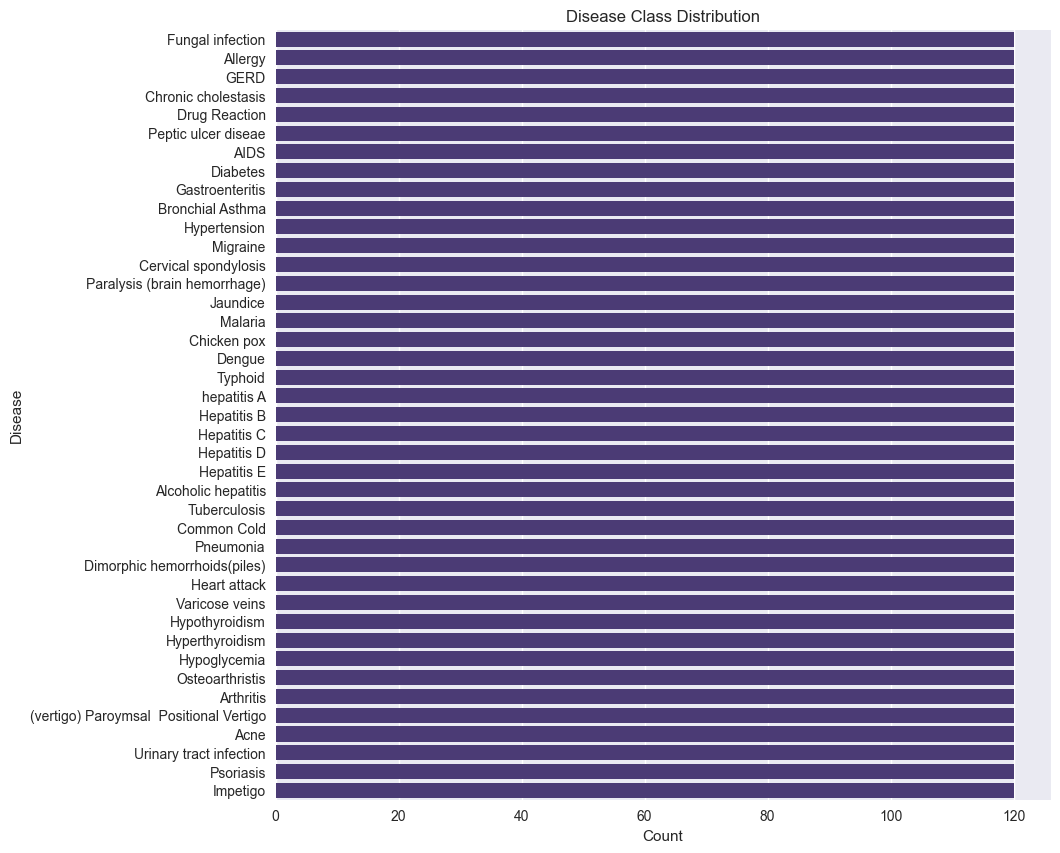

In [8]:
# --- Target Distribution ---
plt.figure(figsize=(10,10))
sns.countplot(y=y, order=y.value_counts().index)
plt.title("Disease Class Distribution")
plt.xlabel("Count")
plt.ylabel("Disease")
plt.show()

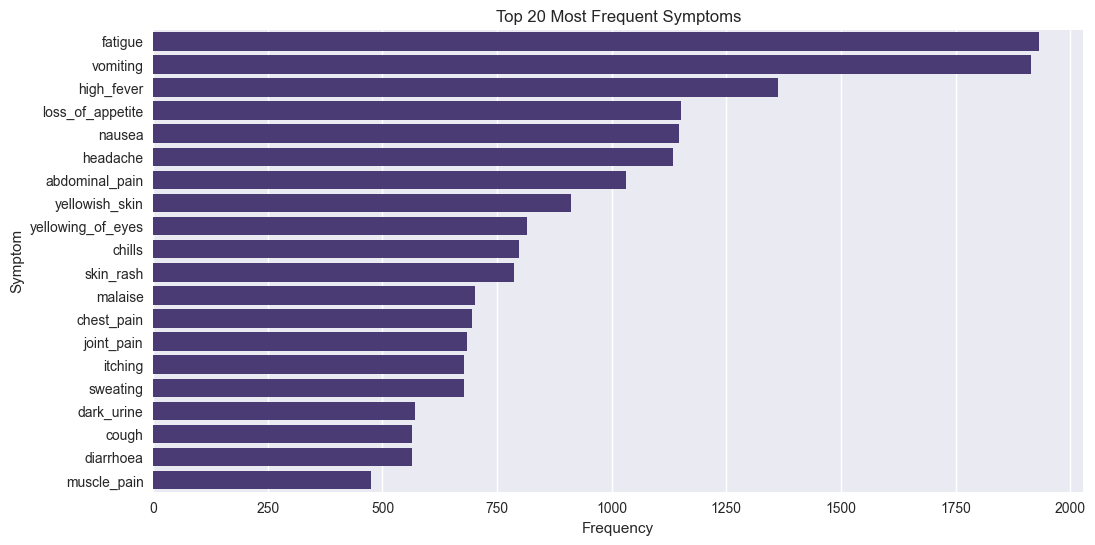

In [11]:
# --- Symptom Frequency ---
symptom_freq = X.sum().sort_values(ascending=False)[:20]
plt.figure(figsize=(12,6))
sns.barplot(x=symptom_freq.values, y=symptom_freq.index)
plt.title("Top 20 Most Frequent Symptoms")
plt.xlabel("Frequency")
plt.ylabel("Symptom")
plt.show()

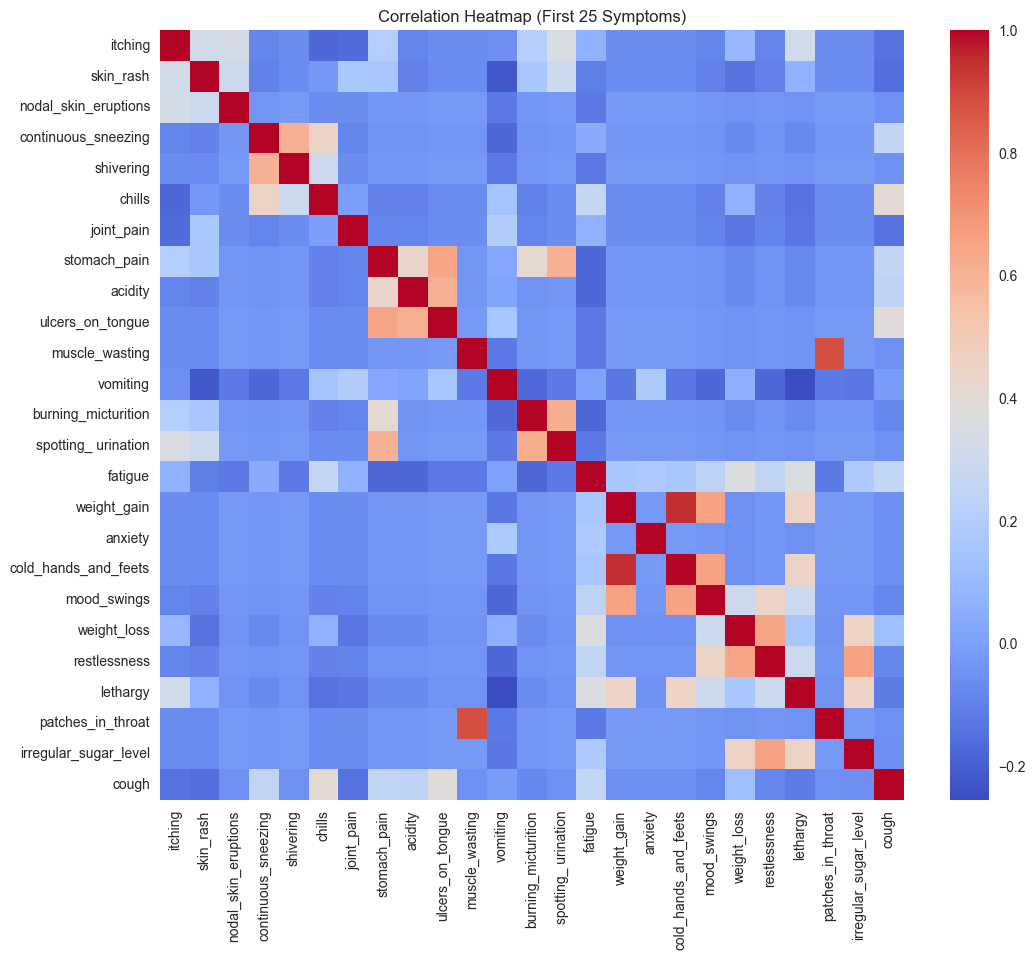

In [18]:
# --- Correlation Heatmap (sample for first 25 symptoms to avoid clutter) ---
plt.figure(figsize=(12,10))
sns.heatmap(X.iloc[:, :25].corr(), cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap (First 25 Symptoms)")
plt.show()

### Model Training

In [19]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Save trained model
model_dir = 'backend/Training/Model'
os.makedirs(model_dir, exist_ok=True)
with open(os.path.join(model_dir, 'model.pkl'), 'wb') as f:
    pickle.dump(model, f)

print("✅ Model training completed and saved at:", os.path.join(model_dir, 'model.pkl'))

✅ Model training completed and saved at: backend/Training/Model\model.pkl


### Model Evaluation

In [20]:
y_pred = model.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Model Accuracy:", round(acc * 100, 2), "%")

Model Accuracy: 100.0 %


In [21]:
# Classification Report
print("\n=== Classification Report ===\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


=== Classification Report ===

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.00      

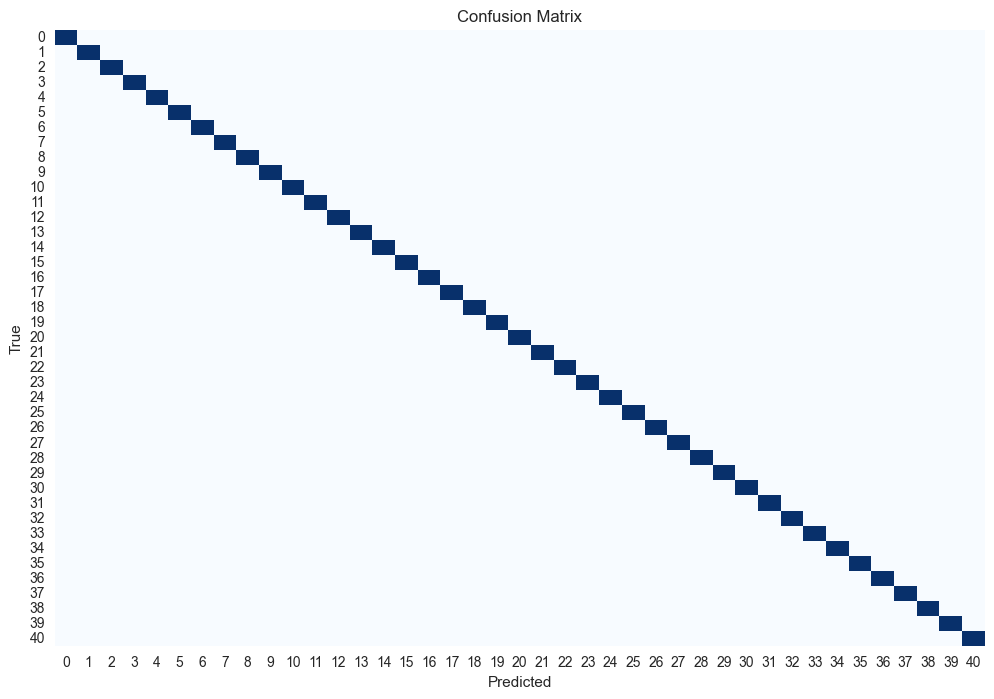

In [23]:
# Confusion Matrix
plt.figure(figsize=(12,8))
sns.heatmap(confusion_matrix(y_test, y_pred), cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()